# NV-to-Lab-Frame Calibration: Building the empirical response matrix from displacement-resolved ODMR pair splittings

This notebook is the first step in reconstructing the magnetic field geometry seen by a [100]-cut NV-diamond sample in the lab frame.

## Goal of this notebook
  
We use the fitted outputs from the previous notebook to build the **empirical response matrix** of the four ODMR dip pairs under controlled small displacements along the laboratory \(x\), \(y\), and \(z\) directions.

The main output of this notebook is a \(4\times 3\) matrix
\[
M_{\mathrm{meas}}=
\begin{pmatrix}
m_{1x} & m_{1y} & m_{1z}\\
m_{2x} & m_{2y} & m_{2z}\\
m_{3x} & m_{3y} & m_{3z}\\
m_{4x} & m_{4y} & m_{4z}
\end{pmatrix},
\]
where \(m_{pa}\) is the slope of the splitting of measured dip pair \(p\) with respect to displacement along lab axis \(a\).

## Physical meaning
For each fitted dip pair \(p\), we define the central-hyperfine pair splitting
\[
\Delta f_p = f_{p,+} - f_{p,-},
\]
using the fitted central hyperfine frequencies \(x_1\) from the Lorentzian global fits.

For small sample translations around the measurement starting point,
\[
\mathbf B(\mathbf r_0 + \delta \mathbf r)\approx \mathbf B_0 + G\,\delta \mathbf r,
\]
where \(G\) is the local field-gradient tensor in the lab frame.

To first order, the ODMR splitting of each NV class changes linearly with displacement, so we model
\[
\Delta f_p(\delta a)\approx \Delta f_{p,0} + m_{pa}\,\delta a,
\]
for \(a\in\{x,y,z\}\).

The matrix \(M_{\mathrm{meas}}\) is therefore the experimental fingerprint of how the four unknown NV-axis channels respond to motion in the three lab directions. In the next notebook, this matrix will be matched to the tetrahedral \(\langle111\rangle\) geometry of a [100]-cut diamond in order to determine the dip-pair assignment and the lab-to-diamond rotation matrix.

## Why this step is needed
Recent work on NV vector magnetometry emphasizes that correct field reconstruction depends critically on handling orientation ambiguities and using the full frequency information carefully. In ensemble ODMR, dip assignment can become ambiguous if one relies only on static spectral appearance. Here we use the whole displacement dataset to produce a cleaner geometric observable before attempting full reconstruction.

## Literature basis
This notebook is motivated by:
- Dennis Lönard et al., *Limits of absolute vector magnetometry with NV centers in diamond*
- Pralekh Dubey et al., *Magnetic field orientation dependence of continuous-wave optically detected magnetic resonance with nitrogen-vacancy ensembles*
- Timo Weggler et al., *Determination of the 3D Magnetic Field Vector Orientation with NV Centers in Diamond*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from scipy.stats import linregress

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Data source and folder structure

This notebook reads the outputs produced by the previous fitting notebook, assumed to live in

\[
\texttt{../fitting\_odmr/batch\_fit\_outputs\_lorentzian}
\]

with subfolders

- `Variation Along X`
- `Variation Along Y`
- `Variation Along Z`

and one folder per displacement point, each containing at least:
- `paired_dips.csv`
- `fitted_dips.csv`
- `fit_metadata.json` (optional here)

The key quantity used in this notebook is the pair splitting stored in `paired_dips.csv`:
\[
\Delta f_p = f_{p,+} - f_{p,-}.
\]

We keep the pair centers only as a diagnostic. For the response matrix, the splitting is the main observable because it tracks the directional magnetic response more directly than the pair center.

In [2]:
# Adjust this only if your relative folder structure changes
ROOT = Path("../fitting_odmr/batch_fit_outputs_lorentzian")

VARIATION_TO_AXIS = {
    "Variation Along X": "x",
    "Variation Along Y": "y",
    "Variation Along Z": "z",
}

for variation in VARIATION_TO_AXIS:
    path = ROOT / variation
    print(f"{variation}: {'FOUND' if path.exists() else 'MISSING'} -> {path}")

Variation Along X: FOUND -> ../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along X
Variation Along Y: FOUND -> ../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along Y
Variation Along Z: FOUND -> ../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along Z


## Helper: displacement parsing

The previous notebook stored one folder per averaged displacement point, with names such as

- `0cm`
- `0cm-0.1mm`

We convert these names into a signed displacement in millimeters.

The sign convention is not merely cosmetic: the response slopes
\[
m_{pa} = \frac{\partial \Delta f_p}{\partial a}
\]
depend on the direction of motion. Therefore, the displacement parser must preserve signs correctly.

In [3]:
def parse_offset_mm(name: str) -> float:
    """
    Extract signed displacement in mm from folder names such as:
    '0cm', '0cm-0.1mm', '0cm+0.2mm'
    """
    name = name.strip().replace(" ", "")
    if name == "0cm":
        return 0.0

    m = re.search(r'([+-]\d+(?:\.\d+)?)mm', name)
    if m:
        return float(m.group(1))

    # fallback: explicit 0cm±...mm format
    m = re.search(r'0cm([+-]\d+(?:\.\d+)?)mm', name)
    if m:
        return float(m.group(1))

    raise ValueError(f"Could not parse displacement from folder name: {name}")

## Loading one run

For each displacement point, we read `paired_dips.csv`.

Each row of `paired_dips.csv` corresponds to one proposed dip pair and contains:
- the fitted left central hyperfine frequency \(f_{p,-}\),
- the fitted right central hyperfine frequency \(f_{p,+}\),
- the splitting
  \[
  \Delta f_p = f_{p,+} - f_{p,-},
  \]
- the pair midpoint relative to the fitted effective center \(D_{\mathrm{eff}}\).

At this stage we do **not** assume these pair IDs are already mapped to crystallographic axes \(d1,\dots,d4\). They are treated only as four measured channels, \(p=1,\dots,4\).

In [4]:
def load_one_pair_file(pair_csv: Path, variation: str, run_name: str) -> pd.DataFrame:
    """
    Load one paired_dips.csv and attach metadata.
    """
    df = pd.read_csv(pair_csv)
    df = df.copy()

    df["variation"] = variation
    df["lab_axis"] = VARIATION_TO_AXIS[variation]
    df["run_name"] = run_name
    df["offset_mm"] = parse_offset_mm(run_name)

    required_cols = [
        "pair_id",
        "left_center_x1_GHz",
        "right_center_x1_GHz",
        "splitting_MHz",
        "pair_center_GHz",
        "pair_center_minus_D_eff_MHz",
        "D_eff_GHz",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {pair_csv}: {missing}")

    return df

## Load the full displacement dataset

We now collect all pair tables from the three scan folders and combine them into one long dataframe.

The resulting dataframe is the raw material for the empirical calibration step:
for each measured pair \(p\), and for each lab axis \(a\in\{x,y,z\}\), we will later fit
\[
\Delta f_p(\delta a)\approx \Delta f_{p,0} + m_{pa}\,\delta a.
\]

In [5]:
all_pair_rows = []

for variation in VARIATION_TO_AXIS:
    variation_dir = ROOT / variation
    if not variation_dir.exists():
        print(f"Skipping missing folder: {variation_dir}")
        continue

    run_dirs = sorted([p for p in variation_dir.iterdir() if p.is_dir()])

    for run_dir in run_dirs:
        pair_csv = run_dir / "paired_dips.csv"
        if not pair_csv.exists():
            print(f"Missing paired_dips.csv in {run_dir}")
            continue

        df_run = load_one_pair_file(pair_csv, variation=variation, run_name=run_dir.name)
        all_pair_rows.append(df_run)

pairs_long = pd.concat(all_pair_rows, ignore_index=True)
pairs_long = pairs_long.sort_values(["variation", "offset_mm", "pair_id"]).reset_index(drop=True)

print(f"Loaded {len(pairs_long)} pair rows")
display(pairs_long.head(12))

Loaded 64 pair rows


,pair_id,left_dip_id_sorted,right_dip_id_sorted,left_center_x1_GHz,right_center_x1_GHz,left_center_x1_err_MHz,right_center_x1_err_MHz,pair_center_GHz,pair_center_minus_D_eff_MHz,splitting_GHz,splitting_MHz,zeeman_half_MHz,left_contrast,right_contrast,D_eff_GHz,variation,lab_axis,run_name,offset_mm
0,1,1,8,2.807770,2.933508,0.080460,0.098631,2.870639,-0.936995,0.125738,125.738095,62.869048,0.011629,0.009366,2.871576,Variation Along X,x,0cm-0.4mm,-0.4
1,2,2,7,2.818928,2.923713,0.033222,0.043665,2.871320,-0.255599,0.104785,104.785094,52.392547,0.028278,0.021649,2.871576,Variation Along X,x,0cm-0.4mm,-0.4
2,3,3,6,2.835220,2.908747,0.069484,0.072435,2.871983,0.407387,0.073527,73.526805,36.763402,0.013448,0.012971,2.871576,Variation Along X,x,0cm-0.4mm,-0.4
3,4,4,5,2.846094,2.898628,0.037257,0.040409,2.872361,0.785207,0.052535,52.534524,26.267262,0.025095,0.023271,2.871576,Variation Along X,x,0cm-0.4mm,-0.4
4,1,1,8,2.808500,2.932712,0.094134,0.098965,2.870606,-0.938357,0.124211,124.211408,62.105704,0.011304,0.010957,2.871544,Variation Along X,x,0cm-0.3mm,-0.3
5,2,2,7,2.819427,2.923169,0.036790,0.054942,2.871298,-0.246403,0.103742,103.741528,51.870764,0.029376,0.019723,2.871544,Variation Along X,x,0cm-0.3mm,-0.3
6,3,3,6,2.835074,2.908740,0.069399,0.075559,2.871907,0.362643,0.073666,73.666087,36.833043,0.015452,0.014329,2.871544,Variation Along X,x,0cm-0.3mm,-0.3
7,4,4,5,2.845667,2.899066,0.042661,0.049868,2.872366,0.822117,0.053400,53.399657,26.699828,0.025473,0.021566,2.871544,Variation Along X,x,0cm-0.3mm,-0.3
8,1,1,8,2.809269,2.932084,0.077486,0.089796,2.870676,-0.863177,0.122815,122.814939,61.407470,0.013163,0.011190,2.871539,Variation Along X,x,0cm-0.2mm,-0.2
9,2,2,7,2.819939,2.922639,0.035246,0.050173,2.871289,-0.250149,0.102700,102.700289,51.350144,0.029105,0.020220,2.871539,Variation Along X,x,0cm-0.2mm,-0.2


## Basic sanity checks

Before building the response matrix, we verify:

1. each run has exactly 4 dip pairs,
2. the pair IDs are consistent within each file,
3. all three scan directions are present,
4. the displacement grid is sensible.

These checks matter because the response matrix is only meaningful if the same four measured channels are tracked consistently across the displacement series.

In [6]:
# Check 4 pairs per run
pairs_per_run = (
    pairs_long.groupby(["variation", "run_name"])["pair_id"]
    .nunique()
    .reset_index(name="n_pairs")
)

display(pairs_per_run.head(10))
print("Unique n_pairs per run:", sorted(pairs_per_run["n_pairs"].unique()))

# Check available offsets
offset_overview = (
    pairs_long.groupby(["variation", "lab_axis"])["offset_mm"]
    .unique()
    .reset_index()
)
display(offset_overview)

,variation,run_name,n_pairs
0,Variation Along X,0cm-0.0mm,4
1,Variation Along X,0cm-0.1mm,4
2,Variation Along X,0cm-0.2mm,4
3,Variation Along X,0cm-0.3mm,4
4,Variation Along X,0cm-0.4mm,4
5,Variation Along Y,0cm-0.0mm,4
6,Variation Along Y,0cm-0.1mm,4
7,Variation Along Y,0cm-0.2mm,4
8,Variation Along Y,0cm-0.3mm,4
9,Variation Along Y,0cm-0.4mm,4


Unique n_pairs per run: [np.int64(4)]


,variation,lab_axis,offset_mm
0,Variation Along X,x,"[-0.4, -0.3, -0.2, -0.1, -0.0]"
1,Variation Along Y,y,"[-0.4, -0.3, -0.2, -0.1, -0.0]"
2,Variation Along Z,z,"[-0.5, -0.4, -0.3, -0.2, -0.1, -0.0]"


## Visual inspection of splitting vs displacement

Before fitting slopes, it is useful to inspect the raw displacement trends.

For each measured pair \(p\), and for each lab scan direction, we plot
\[
\Delta f_p(\delta a)
\]
against displacement \(\delta a\).

If the field is well approximated locally by a linear expansion,
\[
\mathbf B(\mathbf r_0+\delta \mathbf r)\approx \mathbf B_0 + G\,\delta \mathbf r,
\]
then these curves should be approximately linear near the origin.

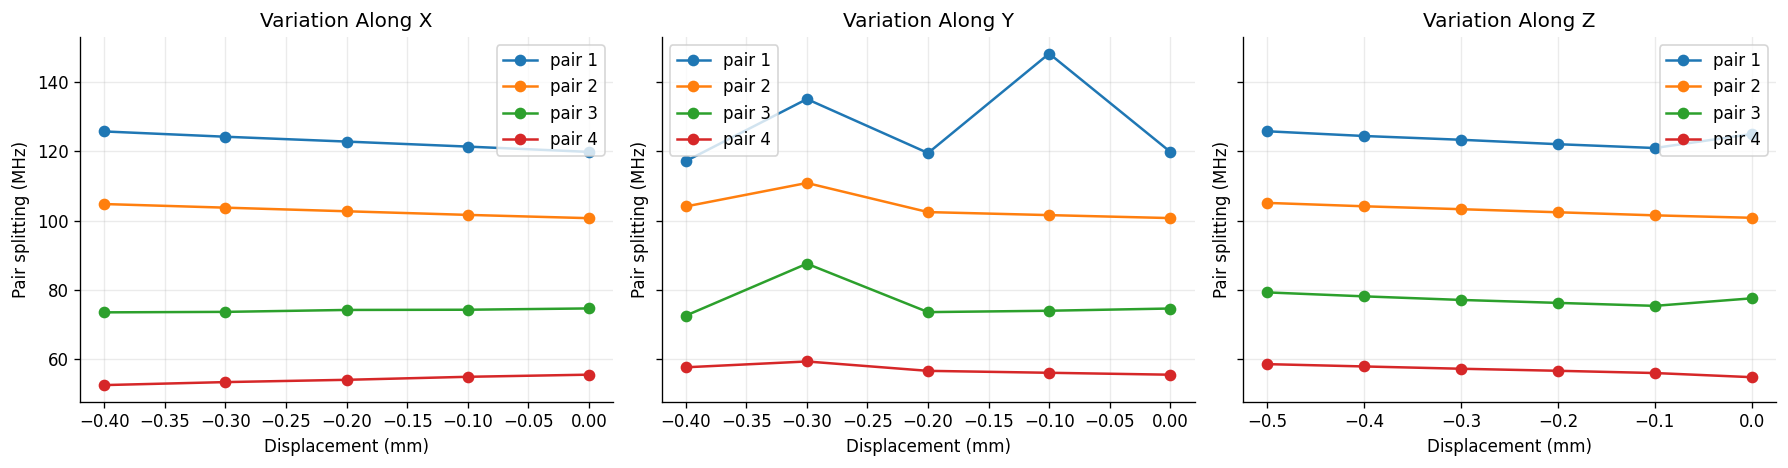

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax_plot, (variation, lab_axis) in zip(axes, VARIATION_TO_AXIS.items()):
    sub = pairs_long[pairs_long["variation"] == variation]

    for pair_id in sorted(sub["pair_id"].unique()):
        d = sub[sub["pair_id"] == pair_id].sort_values("offset_mm")
        ax_plot.plot(d["offset_mm"], d["splitting_MHz"], marker="o", label=f"pair {pair_id}")

    ax_plot.set_title(f"{variation}")
    ax_plot.set_xlabel("Displacement (mm)")
    ax_plot.set_ylabel("Pair splitting (MHz)")
    ax_plot.legend()

plt.tight_layout()
plt.show()


#Limits of absolute vector magnetometry with NV centers in diamond
#Dennis Lönard, Isabel Cardoso Barbosa, Stefan Johansson, Jonas Gutsche, Artur Widera
#The nitrogen-vacancy (NV) center in diamond has become a widely used platform for quantum sensing. 
#AND Shim et al. explicitly discuss second-order off-axis terms and state that the resonance shift asymmetry arises from the nonlinear response to off-axis magnetic field in the presence of zero-field splitting

## From displacement trends to the empirical response matrix

For each measured pair \(p\in\{1,2,3,4\}\) and each scan axis \(a\in\{x,y,z\}\), we fit a straight line
\[
\Delta f_p(\delta a)=b_{pa}+m_{pa}\,\delta a,
\]
where:
- \(b_{pa}\) is the intercept,
- \(m_{pa}\) is the slope in units of MHz/mm.

The slope
\[
m_{pa} = \frac{\partial \Delta f_p}{\partial a}
\]
is the empirical response of pair \(p\) to motion along lab axis \(a\).

Collecting these slopes into a matrix gives
\[
M_{\mathrm{meas}}=
\begin{pmatrix}
m_{1x} & m_{1y} & m_{1z}\\
m_{2x} & m_{2y} & m_{2z}\\
m_{3x} & m_{3y} & m_{3z}\\
m_{4x} & m_{4y} & m_{4z}
\end{pmatrix}.
\]

This is the central output of the notebook. In the next stage, this matrix will be compared against the response expected from the rotated tetrahedral NV-axis set of a [100]-cut diamond.

In [8]:
def fit_splitting_slope(df_axis_pair: pd.DataFrame) -> dict:
    """
    Fit splitting_MHz vs offset_mm with a straight line.
    Returns slope, intercept, R^2, stderr, etc.
    """
    d = df_axis_pair.sort_values("offset_mm")
    x = d["offset_mm"].to_numpy(dtype=float)
    y = d["splitting_MHz"].to_numpy(dtype=float)

    fit = linregress(x, y)

    return {
        "n_points": len(d),
        "slope_MHz_per_mm": fit.slope,
        "intercept_MHz": fit.intercept,
        "r_value": fit.rvalue,
        "r_squared": fit.rvalue**2,
        "p_value": fit.pvalue,
        "slope_stderr": fit.stderr,
        "intercept_stderr": getattr(fit, "intercept_stderr", np.nan),
    }

In [9]:
slope_rows = []

for variation, lab_axis in VARIATION_TO_AXIS.items():
    sub_var = pairs_long[pairs_long["variation"] == variation]

    for pair_id in sorted(sub_var["pair_id"].unique()):
        sub_pair = sub_var[sub_var["pair_id"] == pair_id]
        fit_res = fit_splitting_slope(sub_pair)

        slope_rows.append({
            "variation": variation,
            "lab_axis": lab_axis,
            "pair_id": pair_id,
            **fit_res,
        })

slopes_df = pd.DataFrame(slope_rows).sort_values(["pair_id", "lab_axis"]).reset_index(drop=True)
display(slopes_df)

,variation,lab_axis,pair_id,n_points,slope_MHz_per_mm,intercept_MHz,r_value,r_squared,p_value,slope_stderr,intercept_stderr
0,Variation Along X,x,1,5,-14.649236,119.863501,-0.999882,0.999764,0.000002,0.129953,0.031832
1,Variation Along Y,y,1,5,18.487918,131.661911,0.218721,0.047839,0.723753,47.620409,11.664570
2,Variation Along Z,z,1,6,-4.474249,122.472254,-0.456151,0.208074,0.363230,4.364396,1.321386
3,Variation Along X,x,2,5,-10.238419,100.670562,-0.999824,0.999648,0.000003,0.110948,0.027177
4,Variation Along Y,y,2,5,-15.983050,100.751215,-0.622339,0.387306,0.262246,11.606302,2.842952
5,Variation Along Z,z,2,6,-8.639640,100.724659,-0.999149,0.998299,0.000001,0.178314,0.053987
6,Variation Along X,x,3,5,2.881705,74.647545,0.975167,0.950951,0.004680,0.377856,0.092556
7,Variation Along Y,y,3,5,-9.463311,74.581214,-0.239557,0.057388,0.697929,22.143188,5.423951
8,Variation Along Z,z,3,6,-5.030490,76.038616,-0.684678,0.468784,0.133466,2.677501,0.810654
9,Variation Along X,x,4,5,7.541552,55.600516,0.998473,0.996948,0.000072,0.240908,0.059010


In [10]:
#This matrix is still expressed in terms of **measured dip-pair channels**, not yet crystallographic NV labels. The entire purpose of the next notebook section will be to interpret these four measured rows as one permuted and rotated tetrahedral set.

response_matrix = (
    slopes_df.pivot(index="pair_id", columns="lab_axis", values="slope_MHz_per_mm")
    .reindex(index=[1, 2, 3, 4], columns=["x", "y", "z"])
)

response_matrix_err = (
    slopes_df.pivot(index="pair_id", columns="lab_axis", values="slope_stderr")
    .reindex(index=[1, 2, 3, 4], columns=["x", "y", "z"])
)

print("Measured response matrix M_meas [MHz/mm]:")
display(response_matrix)

print("Slope standard errors [MHz/mm]:")
display(response_matrix_err)

Measured response matrix M_meas [MHz/mm]:


lab_axis,x,y,z
pair_id,,,
1,-14.649236,18.487918,-4.474249
2,-10.238419,-15.983050,-8.639640
3,2.881705,-9.463311,-5.030490
4,7.541552,-7.540334,-7.172519


Slope standard errors [MHz/mm]:


lab_axis,x,y,z
pair_id,,,
1,0.129953,47.620409,4.364396
2,0.110948,11.606302,0.178314
3,0.377856,22.143188,2.677501
4,0.240908,3.360402,0.457946


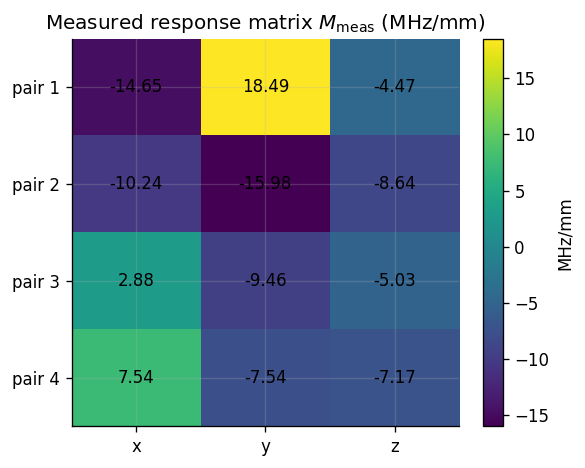

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(response_matrix.to_numpy(dtype=float), aspect="auto")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["x", "y", "z"])
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([f"pair {i}" for i in [1, 2, 3, 4]])
ax.set_title(r"Measured response matrix $M_{\mathrm{meas}}$ (MHz/mm)")

for i in range(response_matrix.shape[0]):
    for j in range(response_matrix.shape[1]):
        val = response_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="MHz/mm")
plt.tight_layout()
plt.show()

## Interpreting the response matrix

Each row of \(M_{\mathrm{meas}}\) is the displacement-response fingerprint of one measured dip pair:
\[
\mathbf m_p = (m_{px},m_{py},m_{pz}).
\]

If the local linear model is valid, each \(\mathbf m_p\) should be related to one crystallographic NV axis through a common lab-to-diamond rotation and a common local field-gradient tensor.

At this stage, the response matrix already contains the essential information needed for the next step:
- enumerate dip-pair assignments,
- enumerate allowed \(\langle111\rangle\) conventions,
- fit one common rotation \(R\),
- fit one common gradient tensor \(G\),
- rank candidates by global residual.

That full constrained matching problem will be implemented next.

## Geometric model: from the measured response matrix to crystal-axis assignment

We now connect the empirical response matrix
\[
M_{\mathrm{meas}}=
\begin{pmatrix}
m_{1x} & m_{1y} & m_{1z}\\
m_{2x} & m_{2y} & m_{2z}\\
m_{3x} & m_{3y} & m_{3z}\\
m_{4x} & m_{4y} & m_{4z}
\end{pmatrix}
\]
to the known tetrahedral geometry of the NV axes in a [100]-cut diamond.

### Crystal-frame NV axes
A convenient diamond-frame representation of the four \(\langle111\rangle\) NV axes is
\[
\hat{\mathbf n}_1=\frac{1}{\sqrt3}(1,1,1),\quad
\hat{\mathbf n}_2=\frac{1}{\sqrt3}(1,-1,-1),
\]
\[
\hat{\mathbf n}_3=\frac{1}{\sqrt3}(-1,1,-1),\quad
\hat{\mathbf n}_4=\frac{1}{\sqrt3}(-1,-1,1).
\]

These four directions form the tetrahedral NV set. The exact labels \(d1,d2,d3,d4\) are convention-dependent; the important thing is that the geometry is fixed up to permutation and sign choices.

### Lab-frame model
Let \(R\) be the unknown rotation matrix from the diamond frame to the lab frame. Then the four NV axes in the lab frame are
\[
\hat{\mathbf n}_i^{(\mathrm{lab})}=R\,\hat{\mathbf n}_i^{(\mathrm{dia})}.
\]

For small displacements around the operating point, we model the field locally as
\[
\mathbf B(\mathbf r_0+\delta\mathbf r)\approx \mathbf B_0+G\,\delta\mathbf r.
\]

Since this notebook works only with pair-splitting slopes, we absorb the magnetic-frequency conversion into an effective gradient matrix \(G_{\mathrm{eff}}\), and write the model response matrix as
\[
M_{\mathrm{model}} = S\,P\,N_{\mathrm{lab}}\,G_{\mathrm{eff}},
\]
where:
- \(N_{\mathrm{lab}}\) is the \(4\times 3\) matrix of rotated NV-axis row vectors,
- \(P\) is a permutation matrix assigning the four crystal axes to the four measured dip pairs,
- \(S=\mathrm{diag}(s_1,s_2,s_3,s_4)\) with \(s_i\in\{\pm1\}\) accounts for branch/sign conventions in the local linearized splitting response.

### Strategy
We will:
1. define the canonical [100]-diamond \(\langle111\rangle\) axis set,
2. enumerate all 24 pair-to-axis permutations,
3. enumerate all 16 sign choices,
4. fit one common rotation matrix \(R\),
5. solve for the best effective gradient matrix \(G_{\mathrm{eff}}\),
6. rank all candidates by weighted residual.

This notebook therefore produces a best-fit **rotation matrix** and a best-fit **dip-pair assignment**, but not yet the magnetic field vector itself.

### Literature context
This step follows the general logic used in NV vector magnetometry and crystallographic orientation analysis:
- Dennis Lönard et al., *Limits of absolute vector magnetometry with NV centers in diamond*
- Pralekh Dubey et al., *Magnetic field orientation dependence of continuous-wave optically detected magnetic resonance with nitrogen-vacancy ensembles*
- Timo Weggler et al., *Determination of the 3D Magnetic Field Vector Orientation with NV Centers in Diamond*

In [12]:
from itertools import permutations, product
from scipy.optimize import minimize

## Canonical [100]-diamond NV axis set

The following code defines the four tetrahedral NV axes in a fixed crystal-frame convention.

The notebook does **not** assume that measured pair 1 is already \(d1\), measured pair 2 is already \(d2\), and so on. That assignment is exactly what we will infer by testing all permutations.

In [13]:
# Canonical diamond-frame NV axes for a [100]-cut diamond
# Rows = crystal-frame axes
N_dia = (1 / np.sqrt(3)) * np.array([
    [ 1,  1,  1],   # d1 convention
    [ 1, -1, -1],   # d2 convention
    [-1,  1, -1],   # d3 convention
    [-1, -1,  1],   # d4 convention
], dtype=float)

N_dia_df = pd.DataFrame(N_dia, index=["d1", "d2", "d3", "d4"], columns=["x_dia", "y_dia", "z_dia"])
display(N_dia_df)

,x_dia,y_dia,z_dia
d1,0.57735,0.57735,0.57735
d2,0.57735,-0.57735,-0.57735
d3,-0.57735,0.57735,-0.57735
d4,-0.57735,-0.57735,0.57735


## Rotation parameterization

We represent the unknown lab-to-diamond orientation by a proper rotation matrix \(R\in SO(3)\).

A convenient parameterization uses three Euler angles:
\[
R = R_z(\gamma)\,R_y(\beta)\,R_x(\alpha).
\]

For any candidate \((P,S)\), we optimize the angles \((\alpha,\beta,\gamma)\).  
For a fixed rotation, the effective gradient matrix \(G_{\mathrm{eff}}\) is solved by linear least squares.

In [14]:
def Rx(alpha):
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [1,  0,   0],
        [0, ca, -sa],
        [0, sa,  ca],
    ], dtype=float)

def Ry(beta):
    cb, sb = np.cos(beta), np.sin(beta)
    return np.array([
        [ cb, 0, sb],
        [  0, 1,  0],
        [-sb, 0, cb],
    ], dtype=float)

def Rz(gamma):
    cg, sg = np.cos(gamma), np.sin(gamma)
    return np.array([
        [cg, -sg, 0],
        [sg,  cg, 0],
        [ 0,   0, 1],
    ], dtype=float)

def rotation_matrix_from_euler_xyz(alpha, beta, gamma):
    """
    Proper rotation matrix.
    Convention used here:
        R = Rz(gamma) @ Ry(beta) @ Rx(alpha)
    mapping diamond-frame vectors into lab-frame vectors.
    """
    return Rz(gamma) @ Ry(beta) @ Rx(alpha)

## Measured matrix and weighting

We now extract the measured slope matrix and its uncertainty matrix from the previous section.

The cost function will be a weighted residual
\[
\chi^2 = \sum_{i,a}\frac{(M_{ia}^{\mathrm{meas}}-M_{ia}^{\mathrm{model}})^2}{\sigma_{ia}^2},
\]
so that response-matrix entries with smaller fitting uncertainty are given more weight.

In [15]:
M_meas = response_matrix.to_numpy(dtype=float)
M_err = response_matrix_err.to_numpy(dtype=float)

# Avoid division by zero or NaN issues in weighting
err_floor = np.nanmedian(M_err[np.isfinite(M_err)])
if not np.isfinite(err_floor) or err_floor == 0:
    err_floor = 1.0

M_err_safe = np.where(np.isfinite(M_err) & (M_err > 0), M_err, err_floor)

print("M_meas shape:", M_meas.shape)
print("M_err_safe shape:", M_err_safe.shape)
print("Median sigma used:", err_floor)

M_meas shape: (4, 3)
M_err_safe shape: (4, 3)
Median sigma used: 1.5677234445196975


## Model for one candidate assignment

For a given:
- permutation \(P\),
- sign pattern \(S\),
- rotation \(R\),

the lab-frame NV-axis matrix is
\[
N_{\mathrm{lab}} = N_{\mathrm{dia}} R^\top,
\]
when the NV axes are stored as row vectors.

Applying permutation and sign convention gives
\[
N_{\mathrm{cand}} = S\,P\,N_{\mathrm{lab}}.
\]

We then fit the effective gradient matrix \(G_{\mathrm{eff}}\) from
\[
M_{\mathrm{meas}} \approx N_{\mathrm{cand}}\,G_{\mathrm{eff}}
\]
by least squares. This lets the optimization focus on the physically constrained geometry, while \(G_{\mathrm{eff}}\) is solved analytically for each trial rotation.

In [25]:
def build_permutation_matrix(perm):
    """
    perm is a tuple of length 4.
    It maps measured pair rows (0..3) to crystal-axis rows in N_dia.
    """
    P = np.zeros((4, 4), dtype=float)
    for row_meas, row_crystal in enumerate(perm):
        P[row_meas, row_crystal] = 1.0
    return P

def build_sign_matrix(signs):
    """
    signs is a tuple/list of 4 entries, each ±1.
    """
    return np.diag(np.asarray(signs, dtype=float))

def candidate_axis_matrix(alpha, beta, gamma, perm, signs):
    """
    Return the candidate 4x3 axis matrix in the measured-pair row order.
    """
    R = rotation_matrix_from_euler_xyz(alpha, beta, gamma)

    # Row-vector representation: v_lab^T = v_dia^T R^T
    N_lab = N_dia @ R.T

    P = build_permutation_matrix(perm)
    S = build_sign_matrix(signs)

    N_cand = S @ P @ N_lab
    return N_cand, R

def fit_gradient_with_common_mode(N_cand, M_meas):
    """
    Fit the augmented model

        M_meas ≈ 1*b^T + N_cand @ G_eff

    where:
        1 is a 4x1 all-ones vector,
        b is a 3-vector of common-mode column offsets,
        G_eff is the 3x3 effective gradient matrix.

    Returns
    -------
    b_vec : (3,) array
        Common-mode offset for each displacement column.
    G_eff : (3, 3) array
        Effective gradient matrix.
    M_model : (4, 3) array
        Best-fit modeled response matrix.
    """
    ones_col = np.ones((N_cand.shape[0], 1), dtype=float)
    X = np.hstack([ones_col, N_cand])   # shape (4, 4)

    beta, *_ = np.linalg.lstsq(X, M_meas, rcond=None)
    # beta shape = (4, 3)
    b_vec = beta[0, :]
    G_eff = beta[1:, :]

    M_model = X @ beta
    return b_vec, G_eff, M_model

## Candidate cost function

The optimization variable is the Euler-angle vector \((\alpha,\beta,\gamma)\).

For each trial rotation:
1. build the candidate axis matrix,
2. solve \(G_{\mathrm{eff}}\) by least squares,
3. compute the weighted residual between measured and modeled response matrices.

The resulting minimum residual tells us how well one specific dip-pair assignment and sign convention explain the observed displacement response.

In [ ]:
def weighted_residual_cost(
    angles,
    perm,
    signs,
    M_meas,
    M_err_safe,
    lambda_surface=200.0,
):
    alpha, beta, gamma = angles
    N_cand, R = candidate_axis_matrix(alpha, beta, gamma, perm, signs)

    b_vec, G_eff, M_model = fit_gradient_with_common_mode(N_cand, M_meas)

    resid = (M_meas - M_model) / M_err_safe
    chi2_data = np.sum(resid**2)

    # Soft constraint: [100] surface normal should align with lab z
    dia_surface_normal = np.array([1.0, 0.0, 0.0])   # [100]
    lab_surface_normal = np.array([0.0, 0.0, 1.0])   # lab z

    mapped_normal = R @ dia_surface_normal
    cosang = np.dot(mapped_normal, lab_surface_normal) / (
        np.linalg.norm(mapped_normal) * np.linalg.norm(lab_surface_normal)
    )

    # abs() allows unknown sign convention for the normal direction
    surface_penalty = lambda_surface * (1.0 - np.abs(cosang))**2

    return chi2_data + surface_penalty

## Multi-start optimization

Because the cost landscape may contain several local minima related to crystal symmetries, we use multiple initial angle guesses for each candidate.

This does not remove symmetry-related degeneracy completely, but it makes the candidate ranking much more reliable.

In [18]:
angle_starts = [
    np.array([0.0, 0.0, 0.0]),
    np.array([ np.pi/6, 0.0, 0.0]),
    np.array([0.0,  np.pi/6, 0.0]),
    np.array([0.0, 0.0,  np.pi/6]),
    np.array([ np.pi/4,  np.pi/6, -np.pi/8]),
    np.array([-np.pi/4,  np.pi/5,  np.pi/7]),
    np.array([ np.pi/3, -np.pi/6,  np.pi/9]),
]

## Enumerating all assignments and sign conventions

We now evaluate all:
- \(4! = 24\) pair-to-axis permutations,
- \(2^4 = 16\) sign conventions,

for a total of 384 candidate families.

For each family we optimize the rotation angles, solve the effective gradient matrix, and store:
- the best-fit residual,
- the best-fit rotation matrix,
- the best-fit \(G_{\mathrm{eff}}\),
- the predicted response matrix.

In [ ]:
    candidate_results = []

    all_perms = list(permutations(range(4)))             # 24
    all_signs = list(product([-1, 1], repeat=4))        # 16

    print(f"Testing {len(all_perms)} permutations × {len(all_signs)} sign patterns = {len(all_perms)*len(all_signs)} candidates")

    for perm in all_perms:
        for signs in all_signs:
            best_local = None

            for start in angle_starts:
                res = minimize(
                    weighted_residual_cost,
                    x0=start,
                    args=(perm, signs, M_meas, M_err_safe),
                    method="L-BFGS-B",
                )

                if (best_local is None) or (res.fun < best_local.fun):
                    best_local = res

            alpha, beta, gamma = best_local.x
    N_cand, R_best = candidate_axis_matrix(alpha, beta, gamma, perm, signs)
    b_vec_best, G_eff_best, M_model_best = fit_gradient_with_common_mode(N_cand, M_meas)

    resid = M_meas - M_model_best
    weighted_resid = resid / M_err_safe
    chi2_data = np.sum(weighted_resid**2)
    rms = np.sqrt(np.mean(resid**2))

    dia_surface_normal = np.array([1.0, 0.0, 0.0])
    lab_surface_normal = np.array([0.0, 0.0, 1.0])
    mapped_normal = R_best @ dia_surface_normal
    cosang = np.dot(mapped_normal, lab_surface_normal) / (
        np.linalg.norm(mapped_normal) * np.linalg.norm(lab_surface_normal)
    )

    candidate_results.append({
        "perm": perm,
        "signs": signs,
        "alpha_rad": alpha,
        "beta_rad": beta,
        "gamma_rad": gamma,
        "chi2": float(best_local.fun),          # includes surface penalty
        "chi2_data_only": float(chi2_data),
        "rms_MHz_per_mm": float(rms),
        "surface_cosine_abs": float(np.abs(cosang)),
        "success": bool(best_local.success),
        "message": best_local.message,
        "R_best": R_best,
        "N_cand": N_cand,
        "b_vec_best": b_vec_best,
        "G_eff_best": G_eff_best,
        "M_model_best": M_model_best,
    })

    print(f"Finished {len(candidate_results)} candidate fits")

Testing 24 permutations × 16 sign patterns = 384 candidates
Finished 384 candidate fits


## Ranking the candidates

We now sort the candidates by residual.

Because symmetry-related near-degeneracies are expected in NV-axis assignment problems, it is normal for several top candidates to have similar residuals. The important thing is to identify:
- the best-fit family,
- whether a few top candidates are effectively equivalent by symmetry,
- and whether the winning rotation is physically sensible relative to the experimental geometry.

In [20]:
ranked_rows = []
for i, row in enumerate(candidate_results):
    ranked_rows.append({
        "rank_placeholder": i,
        "perm": row["perm"],
        "signs": row["signs"],
        "alpha_deg": np.degrees(row["alpha_rad"]),
        "beta_deg": np.degrees(row["beta_rad"]),
        "gamma_deg": np.degrees(row["gamma_rad"]),
        "chi2": row["chi2"],
        "rms_MHz_per_mm": row["rms_MHz_per_mm"],
        "success": row["success"],
    })

ranked_df = pd.DataFrame(ranked_rows).sort_values(["chi2", "rms_MHz_per_mm"]).reset_index(drop=True)
ranked_df.insert(0, "rank", np.arange(1, len(ranked_df) + 1))

display(ranked_df.head(15))

,rank,rank_placeholder,perm,signs,alpha_deg,beta_deg,gamma_deg,chi2,rms_MHz_per_mm,success
0,1,281,"(2, 3, 1, 0)","(1, -1, -1, 1)",-4.499991e+01,3.600008e+01,2.571397e+01,18.105727,5.261248,True
1,2,310,"(3, 0, 2, 1)","(-1, 1, 1, -1)",-6.489698e-07,2.346275e-06,3.000000e+01,18.105727,5.261248,True
2,3,214,"(2, 0, 3, 1)","(-1, 1, 1, -1)",6.000000e+01,-3.000000e+01,2.000000e+01,18.105727,5.261248,True
3,4,361,"(3, 2, 0, 1)","(1, -1, -1, 1)",-4.500074e+01,3.600020e+01,2.571455e+01,18.105727,5.261248,True
4,5,118,"(1, 0, 3, 2)","(-1, 1, 1, -1)",2.999996e+01,-1.528455e-05,-2.037940e-05,18.105727,5.261248,True
5,6,134,"(1, 2, 0, 3)","(-1, 1, 1, -1)",-7.554210e-06,-6.714854e-06,-5.455819e-06,18.105727,5.261248,True
6,7,166,"(1, 3, 0, 2)","(-1, 1, 1, -1)",2.109478e-06,3.000000e+01,-2.301249e-06,18.105727,5.261248,True
7,8,22,"(0, 1, 3, 2)","(-1, 1, 1, -1)",0.000000e+00,3.000000e+01,0.000000e+00,18.105727,5.261248,False
8,9,25,"(0, 1, 3, 2)","(1, -1, -1, 1)",-1.701690e-15,3.000000e+01,-8.744798e-16,18.105727,5.261248,True
9,10,377,"(3, 2, 1, 0)","(1, -1, -1, 1)",-2.792329e-04,3.000007e+01,-2.451801e-04,18.105727,5.261248,True


## Interpreting the permutation

The stored permutation uses zero-based crystal-axis indices in the order of the canonical diamond-frame axis list:
- 0 \(\to d1\)
- 1 \(\to d2\)
- 2 \(\to d3\)
- 3 \(\to d4\)

The tuple
\[
(\pi_1,\pi_2,\pi_3,\pi_4)
\]
means:

- measured pair 1 is assigned to crystal axis \(\pi_1\),
- measured pair 2 is assigned to crystal axis \(\pi_2\),
- measured pair 3 is assigned to crystal axis \(\pi_3\),
- measured pair 4 is assigned to crystal axis \(\pi_4\).

We now decode the top candidates in a more readable way.

In [21]:
axis_labels = ["d1", "d2", "d3", "d4"]

def decode_perm(perm):
    return {
        f"pair_{i+1}": axis_labels[perm[i]]
        for i in range(4)
    }

decoded_top = []
for _, row in ranked_df.head(10).iterrows():
    perm = row["perm"]
    signs = row["signs"]
    decoded_top.append({
        "rank": row["rank"],
        "chi2": row["chi2"],
        "rms_MHz_per_mm": row["rms_MHz_per_mm"],
        "pair_1": axis_labels[perm[0]],
        "pair_2": axis_labels[perm[1]],
        "pair_3": axis_labels[perm[2]],
        "pair_4": axis_labels[perm[3]],
        "signs": signs,
        "alpha_deg": row["alpha_deg"],
        "beta_deg": row["beta_deg"],
        "gamma_deg": row["gamma_deg"],
    })

decoded_top_df = pd.DataFrame(decoded_top)
display(decoded_top_df)

,rank,chi2,rms_MHz_per_mm,pair_1,pair_2,pair_3,pair_4,signs,alpha_deg,beta_deg,gamma_deg
0,1,18.105727,5.261248,d3,d4,d2,d1,"(1, -1, -1, 1)",-4.499991e+01,36.000080,2.571397e+01
1,2,18.105727,5.261248,d4,d1,d3,d2,"(-1, 1, 1, -1)",-6.489698e-07,0.000002,3.000000e+01
2,3,18.105727,5.261248,d3,d1,d4,d2,"(-1, 1, 1, -1)",6.000000e+01,-30.000000,2.000000e+01
3,4,18.105727,5.261248,d4,d3,d1,d2,"(1, -1, -1, 1)",-4.500074e+01,36.000205,2.571455e+01
4,5,18.105727,5.261248,d2,d1,d4,d3,"(-1, 1, 1, -1)",2.999996e+01,-0.000015,-2.037940e-05
5,6,18.105727,5.261248,d2,d3,d1,d4,"(-1, 1, 1, -1)",-7.554210e-06,-0.000007,-5.455819e-06
6,7,18.105727,5.261248,d2,d4,d1,d3,"(-1, 1, 1, -1)",2.109478e-06,29.999996,-2.301249e-06
7,8,18.105727,5.261248,d1,d2,d4,d3,"(-1, 1, 1, -1)",0.000000e+00,30.000000,0.000000e+00
8,9,18.105727,5.261248,d1,d2,d4,d3,"(1, -1, -1, 1)",-1.701690e-15,30.000000,-8.744798e-16
9,10,18.105727,5.261248,d4,d3,d2,d1,"(1, -1, -1, 1)",-2.792329e-04,30.000075,-2.451801e-04


In [22]:
#extract winnng candidates
best_row = ranked_df.iloc[0]
best_idx = int(best_row["rank"] - 1)
best = candidate_results[ranked_df.index[0]]

R_best = best["R_best"]
N_best = best["N_cand"]
G_eff_best = best["G_eff_best"]
M_model_best = best["M_model_best"]
M_resid_best = M_meas - M_model_best

print("Best permutation:", best["perm"], "->", decode_perm(best["perm"]))
print("Best signs:", best["signs"])
print("Best chi2:", best["chi2"])
print("Best RMS [MHz/mm]:", best["rms_MHz_per_mm"])
print()

print("Best-fit rotation matrix R (diamond -> lab):")
display(pd.DataFrame(R_best, index=["lab_x", "lab_y", "lab_z"], columns=["dia_x", "dia_y", "dia_z"]))

print("Best-fit candidate NV-axis matrix in measured-pair order (rows = measured pairs, cols = lab x,y,z):")
display(pd.DataFrame(N_best, index=[f"pair {i}" for i in range(1, 5)], columns=["lab_x", "lab_y", "lab_z"]))

print("Best-fit effective gradient matrix G_eff:")
display(pd.DataFrame(G_eff_best, index=["lab_x", "lab_y", "lab_z"], columns=["disp_x", "disp_y", "disp_z"]))

Best permutation: (0, 1, 2, 3) -> {'pair_1': 'd1', 'pair_2': 'd2', 'pair_3': 'd3', 'pair_4': 'd4'}
Best signs: (-1, -1, -1, -1)
Best chi2: 3613.3630077520183
Best RMS [MHz/mm]: 4.700130009410206

Best-fit rotation matrix R (diamond -> lab):


,dia_x,dia_y,dia_z
lab_x,0.866021,0.000006,0.500008
lab_y,0.000000,1.000000,-0.000012
lab_z,-0.500008,0.000010,0.866021


Best-fit candidate NV-axis matrix in measured-pair order (rows = measured pairs, cols = lab x,y,z):


,lab_x,lab_y,lab_z
pair 1,-0.788680,-0.577343,-0.211324
pair 2,-0.211315,0.577343,0.788683
pair 3,0.788674,-0.577357,0.211312
pair 4,0.211321,0.577357,-0.788671


Best-fit effective gradient matrix G_eff:


,disp_x,disp_y,disp_z
lab_x,13.187630,-15.195378,-0.096516
lab_y,3.927714,-14.093509,-2.731183
lab_z,-7.738499,-9.424022,-0.955999


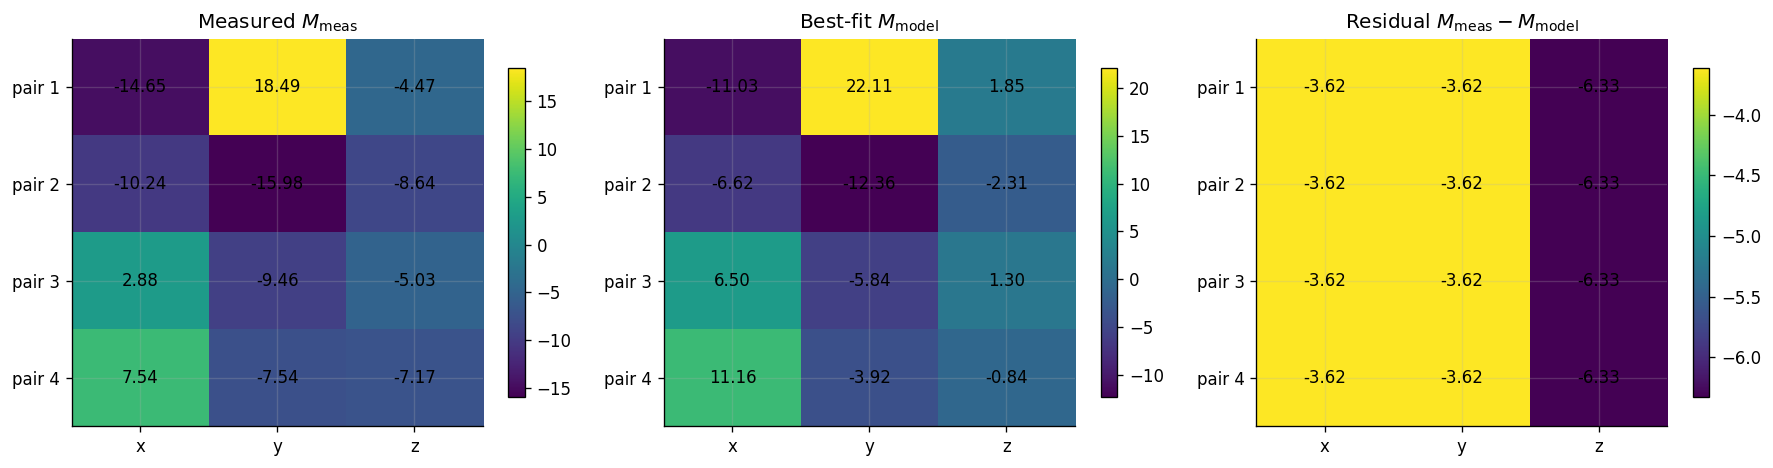

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mat, title in zip(
    axes,
    [M_meas, M_model_best, M_resid_best],
    [r"Measured $M_{\mathrm{meas}}$", r"Best-fit $M_{\mathrm{model}}$", r"Residual $M_{\mathrm{meas}}-M_{\mathrm{model}}$"]
):
    im = ax.imshow(mat, aspect="auto")
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["x", "y", "z"])
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels([f"pair {i}" for i in [1, 2, 3, 4]])
    ax.set_title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()
plt.show()

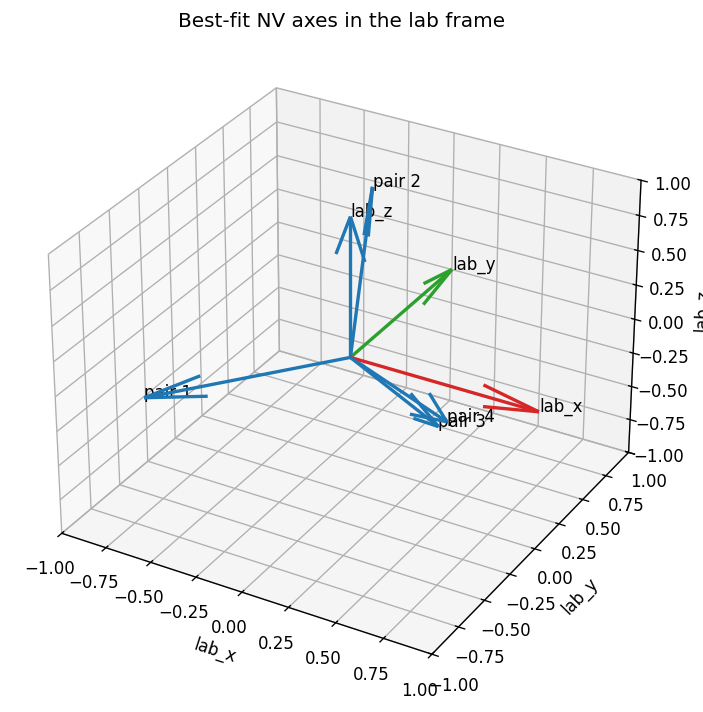

In [24]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

# draw lab axes
origin = np.zeros((3,))
colors = ["tab:red", "tab:green", "tab:blue"]
labels = ["lab_x", "lab_y", "lab_z"]
basis = np.eye(3)

for vec, c, lbl in zip(basis, colors, labels):
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color=c, linewidth=2)
    ax.text(vec[0], vec[1], vec[2], lbl)

# draw NV axes
for i, row in enumerate(N_best, start=1):
    ax.quiver(0, 0, 0, row[0], row[1], row[2], linewidth=2)
    ax.text(row[0], row[1], row[2], f"pair {i}")

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel("lab_x")
ax.set_ylabel("lab_y")
ax.set_zlabel("lab_z")
ax.set_title("Best-fit NV axes in the lab frame")
plt.tight_layout()
plt.show()